# Automated Essay Scoring (AES) with RoBERTa (Regression)

This notebook demonstrates our final AES pipeline on the **ASAP 2.0** dataset:
- Load + clean essays
- Quick EDA (score + length distributions)
- Fine-tune **RoBERTa-base** as a **regression model**
- Evaluate with **Accuracy (rounded), QWK, Pearson, MAE, RMSE**
- Live demo: score a custom essay


In [1]:
import os
import warnings
import logging

os.environ["TOKENIZERS_PARALLELISM"] = "false"
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("datasets").setLevel(logging.ERROR)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore")

logging.getLogger("torch").setLevel(logging.ERROR)
print("Supressing unnecessary warnings")


Supressing unnecessary warnings


In [2]:

os.environ["TOKENIZERS_PARALLELISM"] = "false"  # silence HF tokenizers spam

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    classification_report,
    cohen_kappa_score,
)
from scipy.stats import pearsonr

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

from tqdm.auto import tqdm  # ensure tqdm notebook-friendly
tqdm.pandas()

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


2025-12-13 10:20:33.690278: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765621233.906617      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765621233.971066      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Torch: 2.6.0+cu124
CUDA available: True
Device: cuda


## 1) Load + Clean Data

We apply light cleaning:
- lowercase
- normalize whitespace
- remove punctuation/symbols

Then we compute the score range (1–6) for clipping/rounding.


In [3]:
df = pd.read_csv("/kaggle/input/asap2-dataset/ASAP2_train_sourcetexts.csv")

def clean_text(t):
    t = str(t).lower()
    t = re.sub(r"\s+", " ", t)
    t = re.sub(r"[^a-z0-9\s]", "", t)
    return t.strip()

df["clean_text"] = df["full_text"].apply(clean_text)
df["score"] = df["score"].astype(float)
df.dropna(subset=["clean_text", "score"], inplace=True)

min_score, max_score = df["score"].min(), df["score"].max()
print(df.shape)
print(df["score"].describe())
print("Score range:", min_score, "->", max_score)

df[["essay_id", "prompt_name", "score", "clean_text"]].head()


(24728, 15)
count    24728.000000
mean         2.939987
std          1.035991
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          6.000000
Name: score, dtype: float64
Score range: 1.0 -> 6.0


,essay_id,prompt_name,score,clean_text
0,AAAVUP14319000159574,Exploring Venus,4.0,the author suggests that studying venus is wor...
1,AAAVUP14319000159542,Exploring Venus,2.0,nasa is fighting to be alble to to go to venus...
2,AAAVUP14319000159461,Exploring Venus,3.0,the evening star is one of the brightest point...
3,AAAVUP14319000159420,Exploring Venus,2.0,the author supports this idea because from rea...
4,AAAVUP14319000159419,Exploring Venus,2.0,how the author supports this idea is that he s...


## 2) Quick EDA

We briefly inspect:
- Score distribution
- Essay length distribution
- Relationship between essay length and score (correlation)


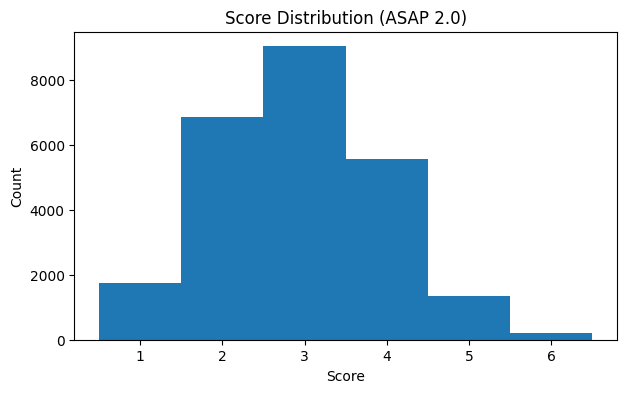

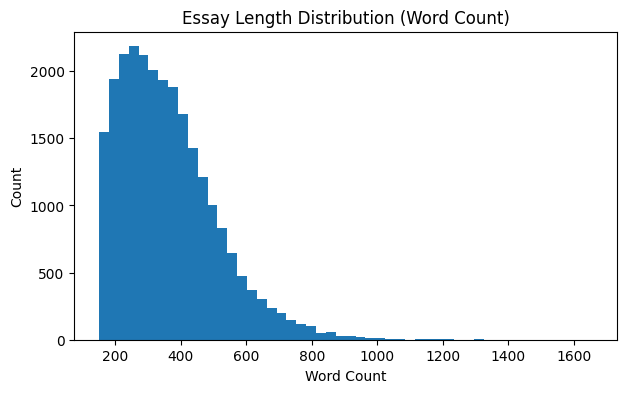

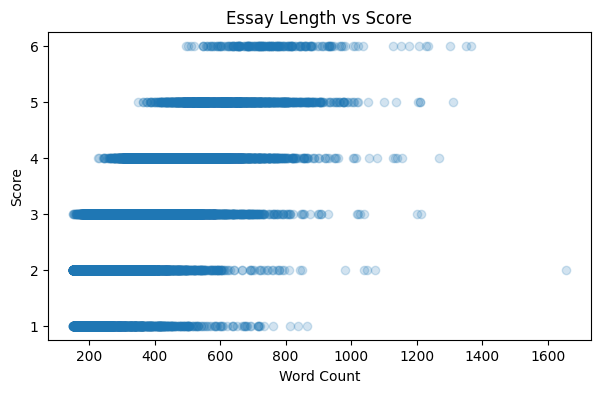

Correlation(word_count, score): 0.708


In [4]:


# Essay length (words)
df["word_count"] = df["clean_text"].apply(lambda x: len(x.split()))

# Score distribution
plt.figure(figsize=(7,4))
plt.hist(df["score"], bins=np.arange(min_score, max_score + 2) - 0.5)
plt.title("Score Distribution (ASAP 2.0)")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

# Word count distribution
plt.figure(figsize=(7,4))
plt.hist(df["word_count"], bins=50)
plt.title("Essay Length Distribution (Word Count)")
plt.xlabel("Word Count")
plt.ylabel("Count")
plt.show()

# Word count vs score
plt.figure(figsize=(7,4))
plt.scatter(df["word_count"], df["score"], alpha=0.2)
plt.title("Essay Length vs Score")
plt.xlabel("Word Count")
plt.ylabel("Score")
plt.show()

corr_len = df[["word_count", "score"]].corr().iloc[0,1]
print(f"Correlation(word_count, score): {corr_len:.3f}")


## 3) Train / Validation / Test Split

We split the dataset into:
- 80% train
- 10% validation
- 10% test

Stratification preserves the score distribution.


In [5]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["score"],
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df["score"],
)

print("Train size:", train_df.shape[0])
print("Val size:  ", val_df.shape[0])
print("Test size: ", test_df.shape[0])

train_ds = Dataset.from_pandas(train_df[["clean_text", "score"]])
val_ds   = Dataset.from_pandas(val_df[["clean_text", "score"]])
test_ds  = Dataset.from_pandas(test_df[["clean_text", "score"]])


Train size: 17803
Val size:   1979
Test size:  4946


## 4) Tokenization

Next we tokenize essays using RoBERTa’s tokenizer and pad to 512 tokens.


In [6]:
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
max_len = 512

def tokenize(batch):
    enc = tokenizer(
        batch["clean_text"],
        truncation=True,
        padding="max_length",
        max_length=max_len,
    )
    enc["labels"] = float(batch["score"])  # regression label
    return enc

train_tok = train_ds.map(tokenize)
val_tok   = val_ds.map(tokenize)
test_tok  = test_ds.map(tokenize)

cols = ["input_ids", "attention_mask", "labels"]
train_tok.set_format(type="torch", columns=cols)
val_tok.set_format(type="torch", columns=cols)
test_tok.set_format(type="torch", columns=cols)

print("Tokenized train example keys:", train_tok[0].keys())


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/17803 [00:00<?, ? examples/s]

Map:   0%|          | 0/1979 [00:00<?, ? examples/s]

Map:   0%|          | 0/4946 [00:00<?, ? examples/s]

Tokenized train example keys: dict_keys(['input_ids', 'attention_mask', 'labels'])


## 5) Model: RoBERTa Regression

We fine-tune RoBERTa-base with a regression head:
- `num_labels=1`
- `problem_type="regression"`

The model predicts a **continuous score**, which we later round to the range [1, 6].


In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=1,
    problem_type="regression",
).to(device)


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Why We Use Regression Instead of Classification

Although ASAP provides **integer scores**, essay grading is an **ordinal, distance-aware task**.  
A prediction of 5 is much closer to 6 than to 1, and errors should be penalized based on how far
they are from the true score.

Therefore it made sense to model AES as a **regression problem**, predicting a continuous score that is later
rounded to the valid range. This formulation aligns naturally with **Quadratic Weighted Kappa (QWK)**,
the standard evaluation metric for essay scoring.

In our experiments, regression achieved better QWK and Pearson correlation than classification,
so it was chosen for the final model.


## 6) Metrics

We report:
- Accuracy (rounded predictions)
- QWK (Quadratic Weighted Kappa)
- Pearson correlation
- MAE
- RMSE


In [8]:
def compute_metrics(eval_pred):
    preds, labels = eval_pred
    preds = preds.squeeze(-1)         
    labels = labels.astype(float)

    preds_cont = preds
    preds_round = np.clip(np.round(preds_cont), min_score, max_score)

    acc  = accuracy_score(labels, preds_round)
    qwk  = cohen_kappa_score(labels, preds_round, weights="quadratic")
    pear, _ = pearsonr(labels, preds_cont)
    mae  = mean_absolute_error(labels, preds_cont)
    rmse = np.sqrt(mean_squared_error(labels, preds_cont))

    return {
        "accuracy": float(acc),
        "qwk": float(qwk),
        "pearson": float(pear),
        "mae": float(mae),
        "rmse": float(rmse),
    }


## 7) Training Setup

We fine-tune with:
- LR = 2e-5
- 3 epochs
- FP16 on GPU
- Evaluate + save every 500 steps
- Load best checkpoint based on **QWK**


In [9]:
args = TrainingArguments(
    output_dir="./roberta_aes",

    learning_rate=2e-5,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,

    fp16=True,
    dataloader_num_workers=2,

    logging_steps=100,
    eval_steps=500,
    save_steps=500,
    eval_strategy="steps",
    save_strategy="steps",
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="eval_qwk",

    disable_tqdm=False,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

print("Trainer device:", trainer.args.device)


Trainer device: cuda:0


In [10]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy,Qwk,Pearson,Mae,Rmse
500,0.481400,0.416112,0.589692,0.745937,0.806871,0.495454,0.645020
1000,0.407000,0.510913,0.525518,0.695015,0.814725,0.565023,0.714699
1500,0.371600,0.359465,0.626074,0.748109,0.824817,0.458906,0.599479
2000,0.361600,0.360190,0.634159,0.770865,0.831061,0.462335,0.600074
2500,0.289100,0.387675,0.607883,0.774073,0.834697,0.476481,0.622535
3000,0.292500,0.389815,0.617484,0.787302,0.837636,0.479647,0.624257


TrainOutput(global_step=3339, training_loss=0.39662543168572045, metrics={'train_runtime': 3336.1938, 'train_samples_per_second': 16.009, 'train_steps_per_second': 1.001, 'total_flos': 1.4052372184009728e+16, 'train_loss': 0.39662543168572045, 'epoch': 3.0})

## 9) Final Evaluation on Test Set


In [11]:
print("\nTEST METRICS (RoBERTa-base Fine-Tuned)\n")
test_metrics = trainer.evaluate(test_tok)
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

preds = trainer.predict(test_tok)
y_true = preds.label_ids.astype(float)
y_pred_cont = preds.predictions.squeeze(-1)
y_pred_round = np.clip(np.round(y_pred_cont), min_score, max_score)

print("\nClassification report:\n")
print(classification_report(y_true, y_pred_round))



TEST METRICS (RoBERTa-base Fine-Tuned)



eval_loss: 0.4025
eval_accuracy: 0.6116
eval_qwk: 0.7776
eval_pearson: 0.8315
eval_mae: 0.4858
eval_rmse: 0.6344
eval_runtime: 87.4019
eval_samples_per_second: 56.5890
eval_steps_per_second: 3.5470
epoch: 3.0000

Classification report:

              precision    recall  f1-score   support

         1.0       0.76      0.31      0.44       350
         2.0       0.69      0.62      0.66      1370
         3.0       0.64      0.60      0.62      1804
         4.0       0.55      0.71      0.62      1111
         5.0       0.42      0.72      0.53       271
         6.0       0.00      0.00      0.00        40

    accuracy                           0.61      4946
   macro avg       0.51      0.49      0.48      4946
weighted avg       0.63      0.61      0.61      4946



## Confusion Matrix (Rounded Predictions)

The confusion matrix below compares **true essay scores** with **rounded model predictions**.

<Figure size 700x600 with 0 Axes>

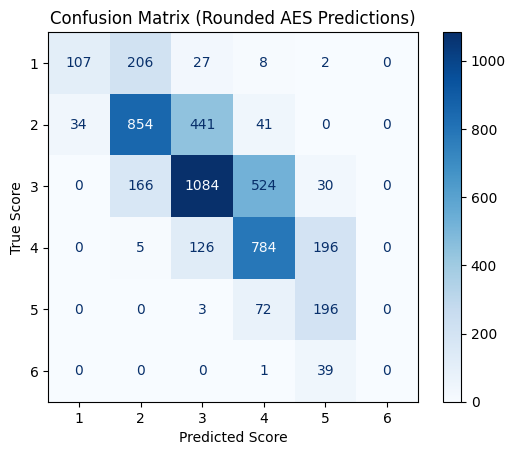

In [12]:
# Confusion matrix using rounded predictions
cm = confusion_matrix(
    y_true,
    y_pred_round,
    labels=list(range(int(min_score), int(max_score) + 1))
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(range(int(min_score), int(max_score) + 1))
)

plt.figure(figsize=(7, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Rounded AES Predictions)")
plt.xlabel("Predicted Score")
plt.ylabel("True Score")
plt.show()


## 10) Scoring an essay sample

We take a raw essay, clean + tokenize it, and get:
- continuous score
- rounded score in range [1, 6]


In [13]:
def score_essay(text: str):
    cleaned = clean_text(text)
    enc = tokenizer(
        cleaned,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        output = model(**enc).logits.squeeze(-1).item()

    continuous = float(output)
    rounded = int(np.clip(np.round(continuous), min_score, max_score))
    return continuous, rounded

sample = """
Education is essential for preparing students for real-world communication.
Writing teaches clarity, argumentation, and critical thinking.
"""

cont, rnd = score_essay(sample)
print("Continuous score:", cont)
print("Rounded score:", rnd)


Continuous score: 2.883206844329834
Rounded score: 3
